## Использование Tensorflow

m:\Code\bfu-ml\.venv\lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


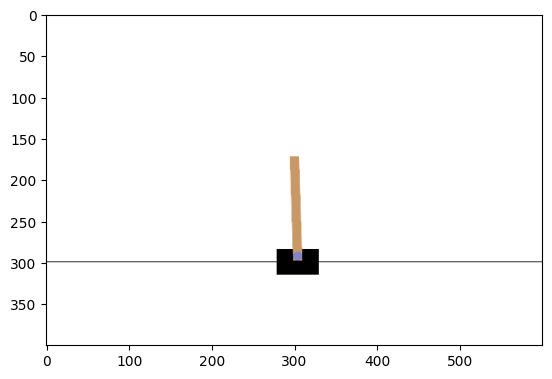

In [6]:
import sys, os 
# Этот код создает виртуальный дисплей для рисования игровых изображений. 
# Это не будет иметь никакого эффекта, если на вашей машине есть монитор. 
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0: 
    os.environ['DISPLAY'] = ':1' 
import gymnasium as gym 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

env = gym.make("CartPole-v0", render_mode='rgb_array').env 
env.reset() 

n_actions = env.action_space.n 
state_dim = env.observation_space.shape 

img = env.render()
plt.imshow(img) 
plt.show()

In [7]:
import tensorflow as tf 
import keras 
import keras.layers as L 

tf.compat.v1.disable_eager_execution()
tf.compat.v1.reset_default_graph()

sess = tf.compat.v1.Session()

gpus = tf.config.list_physical_devices('GPU')
assert not gpus , "Пожалуйста, выполните это задание без графического процессора. Если вы используете \
    графический процессор, код  \
        будет работать намного медленнее из-за большого количества операций копирования в память \
            графического процессора и из нее. \
                Чтобы отключить графический процессор в Colab, выберите «Runtime» → «Change runtime type» → «None»." 
 
network = keras.models.Sequential() 
network.add(L.InputLayer(state_dim)) 
network.add(L.Dense(64, activation="relu"))
network.add(L.Dense(64, activation="relu"))
network.add(L.Dense(n_actions, activation="linear"))

states_ph_1 = tf.compat.v1.placeholder(tf.float32, shape=(None,) + state_dim)
q_values = network(states_ph_1)

sess.run(tf.compat.v1.global_variables_initializer())

def get_action(state, epsilon=0): 
    """ 
    примеры действий с эпсилон-жадной политикой 
     Резюме: с p = epsilon выберите случайное действие, иначе выберите действие с наибольшим Q 
    (s, a) 
    """ 
    if isinstance(state, tuple):
        state = state[0]

    qvalues = sess.run(q_values, feed_dict={states_ph_1: state[None]})[0]
    if np.random.rand() < epsilon:
        return int(np.random.randint(n_actions))
    return int(np.argmax(qvalues))

In [8]:
assert network.output_shape == (None, n_actions), "пожалуйста, убедитесь, что ваша модель отображает состояние s -> [Q(s,a0),..., Q(s, a_last)]"

assert network.layers[-1].activation == keras.activations.linear, "пожалуйста, убедитесь, что вы предсказываете q-значения без нелинейности"

s, _ = env.reset()

assert np.shape(get_action(s)) == (), "верните только одно действие (integer)"

for eps in [0.0, 0.1, 0.5, 1.0]:
    state_frequencies = np.bincount(
        [get_action(s, epsilon=eps) for _ in range(10000)],
        minlength=n_actions
    )
    best_action = state_frequencies.argmax()

    assert abs(state_frequencies[best_action] - 10000 * (1 - eps + eps / n_actions)) < 200
    for other_action in range(n_actions):
        if other_action != best_action:
            assert abs(state_frequencies[other_action] - 10000 * (eps / n_actions)) < 200

    print("e=%.1f tests passed" % eps)

e=0.0 tests passed
e=0.1 tests passed
e=0.5 tests passed
e=1.0 tests passed


In [9]:
# Создание плейсхолдеров для <s, a, r, s'> кортежа и специального индикатора окончания игры (is_done = True)
states_ph = tf.compat.v1.placeholder(dtype=tf.float32, shape=(None,) + state_dim)
actions_ph = tf.compat.v1.placeholder(dtype=tf.int32, shape=[None])
rewards_ph = tf.compat.v1.placeholder(dtype=tf.float32, shape=[None])
next_states_ph = tf.compat.v1.placeholder(dtype=tf.float32, shape=(None,) + state_dim)
is_done_ph = tf.compat.v1.placeholder(dtype=tf.bool, shape=[None])

#задание q-значений для всех действий в текущем состоянии
predicted_qvalues = network(states_ph)
#выборка q-значений для выбранных действий
predicted_qvalues_for_actions = tf.reduce_sum(predicted_qvalues * tf.one_hot(actions_ph, n_actions), axis=1)

gamma = 0.99

# вычислить q-значения для всех действий в следующих состояниях
predicted_next_qvalues = network(next_states_ph)
# вычислить V * (next_states), используя предсказанные следующие q-значения
next_state_values = tf.reduce_max(predicted_next_qvalues, axis=1)
# вычислить «целевые q-значения» для потерь — это то, что находится внутри квадратных скобок в приведенной выше формуле
target_qvalues_for_actions = rewards_ph + gamma * next_state_values
# в последнем состоянии будем использовать упрощенную формулу: Q(s,a) = r(s,a), так как s' несуществует
target_qvalues_for_actions = tf.where(is_done_ph, rewards_ph, target_qvalues_for_actions)

In [10]:
#потери среднеквадратичной ошибки для минимизации 
loss = (predicted_qvalues_for_actions - tf.stop_gradient(target_qvalues_for_actions)) ** 2
loss = tf.reduce_mean(loss)

# обучающая функция, похожая на agent.update(state, action, reward, next_state) из табличного агента 
train_step = tf.compat.v1.train.AdamOptimizer(1e-4).minimize(loss)

assert tf.gradients(loss, [predicted_qvalues_for_actions])[0] is not None, "убедитесь, что вы обновляете q-значения для выбранных действий, а не только для всех действий" 
assert tf.gradients(loss, [predicted_next_qvalues])[0] is None, "убедитесь, что вы не распространяете градиент w.r.t. Q_ (с', а')" 
assert predicted_next_qvalues.shape.ndims == 2, "убедитесь, что вы предсказали значения q для всех действий в следующем состоянии" 
assert next_state_values.shape.ndims == 1, "убедитесь, что вы вычислили V (s') как максимум только по оси действий, а не по всем осям" 
assert target_qvalues_for_actions.shape.ndims == 1, "что-то не так с целевыми значениями q, они должны быть вектором"

In [11]:
sess.run(tf.compat.v1.global_variables_initializer())

def generate_session(env, t_max=1000, epsilon=0, train=False):
    """играть с env с приблизительным агентом q-обучения и одновременно тренировать его"""
    total_reward = 0
    s, _ = env.reset()
    for t in range(t_max):
        a = get_action(s, epsilon=epsilon)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        if train:
            sess.run(train_step, {
                states_ph: [s], actions_ph: [a], rewards_ph: [r],
                next_states_ph: [next_s], is_done_ph: [done]
            })
        total_reward += r
        s = next_s
        if done:
            break
    return total_reward

epsilon = 0.5

for i in range(1000):
    session_rewards = [generate_session(env, epsilon=epsilon, train=True) for _ in range(100)]
    print("epoch #{}:\tmean reward = {:.3f}\tepsilon = {:.3f}".format(i, np.mean(session_rewards), epsilon))
    epsilon *= 0.99
    assert epsilon >= 1e-4, "Убедитесь, что эпсилон всегда отличен от нуля во время обучения"
    if np.mean(session_rewards) > 300:
        print("You Win!")
        break

epoch #0:	mean reward = 14.620	epsilon = 0.500
epoch #1:	mean reward = 13.800	epsilon = 0.495
epoch #2:	mean reward = 12.580	epsilon = 0.490
epoch #3:	mean reward = 14.860	epsilon = 0.485
epoch #4:	mean reward = 16.010	epsilon = 0.480
epoch #5:	mean reward = 13.240	epsilon = 0.475
epoch #6:	mean reward = 13.150	epsilon = 0.471
epoch #7:	mean reward = 12.920	epsilon = 0.466
epoch #8:	mean reward = 15.330	epsilon = 0.461
epoch #9:	mean reward = 13.590	epsilon = 0.457
epoch #10:	mean reward = 16.650	epsilon = 0.452
epoch #11:	mean reward = 15.810	epsilon = 0.448
epoch #12:	mean reward = 17.390	epsilon = 0.443
epoch #13:	mean reward = 32.310	epsilon = 0.439
epoch #14:	mean reward = 39.570	epsilon = 0.434
epoch #15:	mean reward = 51.650	epsilon = 0.430
epoch #16:	mean reward = 56.340	epsilon = 0.426
epoch #17:	mean reward = 68.880	epsilon = 0.421
epoch #18:	mean reward = 79.200	epsilon = 0.417
epoch #19:	mean reward = 111.330	epsilon = 0.413
epoch #20:	mean reward = 121.530	epsilon = 0.409
